In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


####Load the Datasets

In [2]:
apps = pd.read_csv('apps.csv')
reviews = pd.read_csv('user_reviews.csv')

In [9]:
apps.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [10]:
apps.shape

(9659, 14)

In [6]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [11]:
reviews.shape

(64295, 5)

In [12]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [13]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


####Check Missing Values

In [21]:
apps.isnull().sum()

,0
Unnamed: 0,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0


In [20]:
reviews.isnull().sum()

,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


In [18]:
apps.dropna(inplace=True)

In [19]:
reviews.dropna(inplace=True)

####Clean Rating Column

In [22]:
apps = apps[apps['Rating'] <= 5]

In [23]:
apps['Rating'] = apps['Rating'].astype(float)

####Clean Reviews Column

In [24]:
apps['Reviews'] = pd.to_numeric(apps['Reviews'])

####Clean Installs Column

In [25]:
apps['Installs'] = apps['Installs'].str.replace('+','')
apps['Installs'] = apps['Installs'].str.replace(',','')
apps['Installs'] = apps['Installs'].astype(int)

####Clean Price Column

In [26]:
apps['Price'] = apps['Price'].str.replace('$','')
apps['Price'] = apps['Price'].astype(float)

####Clean Size Column

In [31]:
apps['Size'] = apps['Size'].astype(str)
apps['Size'] = apps['Size'].str.replace('M','')
apps['Size'] = apps['Size'].str.replace('k','')
apps['Size'] = apps['Size'].replace('Varies with device',np.nan)
apps['Size'] = pd.to_numeric(apps['Size'],errors='coerce')

In [32]:
apps['Size'] = pd.to_numeric(apps['Size'],errors='coerce')

###Handle Missing Values

In [33]:
apps['Rating'].fillna(apps['Rating'].mean(), inplace=True)
apps['Size'].fillna(apps['Size'].median(), inplace=True)

reviews['Translated_Review'].fillna('', inplace=True)
reviews['Sentiment'].fillna('Neutral', inplace=True)

/tmp/ipykernel_3711/4227167855.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps['Rating'].fillna(apps['Rating'].mean(), inplace=True)
/tmp/ipykernel_3711/4227167855.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

###Number of Apps in Each Category

In [34]:
apps['Category'].value_counts()

,count
Category,
FAMILY,1511
GAME,832
TOOLS,625
PERSONALIZATION,274
LIFESTYLE,269
MEDICAL,266
FINANCE,258
PRODUCTIVITY,223
BUSINESS,222


###Visualize Category Distribution

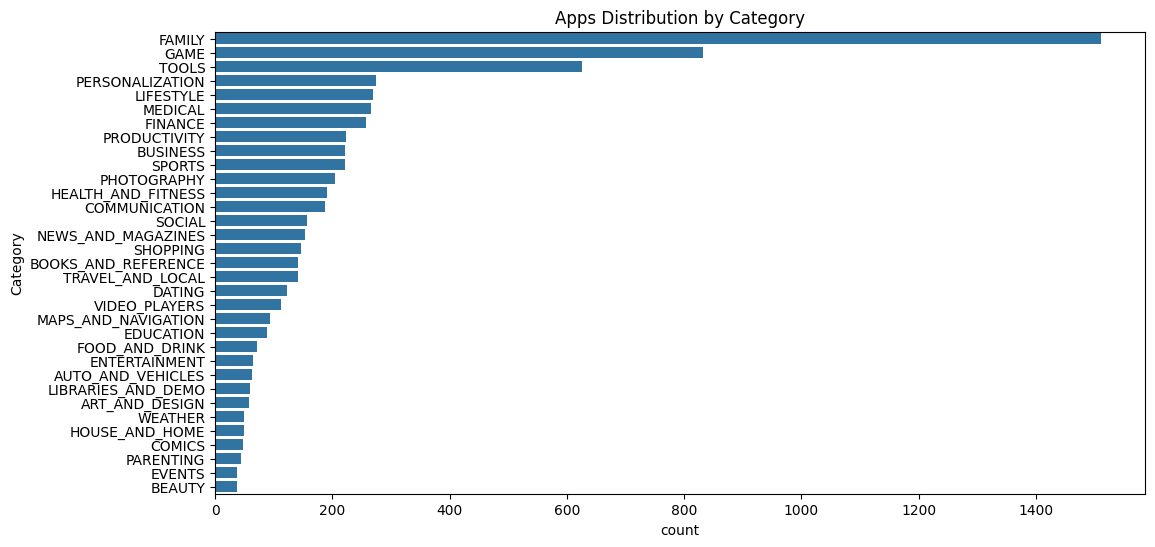

In [35]:
plt.figure(figsize=(12,6))
sns.countplot(y='Category', data=apps,
              order=apps['Category'].value_counts().index)
plt.title('Apps Distribution by Category')
plt.show()

###Analyze Ratings

In [36]:
apps['Rating'].describe()

,Rating
count,7021.000000
mean,4.160704
std,0.559241
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,5.000000


###Visualization

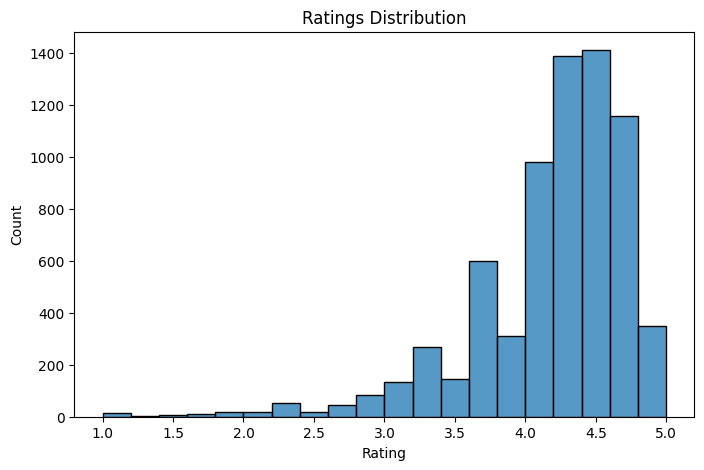

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(apps['Rating'], bins=20)
plt.title('Ratings Distribution')
plt.show()

###Analyze App Size

In [38]:
apps['Size'].describe()

,Size
count,7021.000000
mean,21.767597
std,22.731237
min,0.000000
25%,4.900000
50%,13.000000
75%,31.000000
max,100.000000


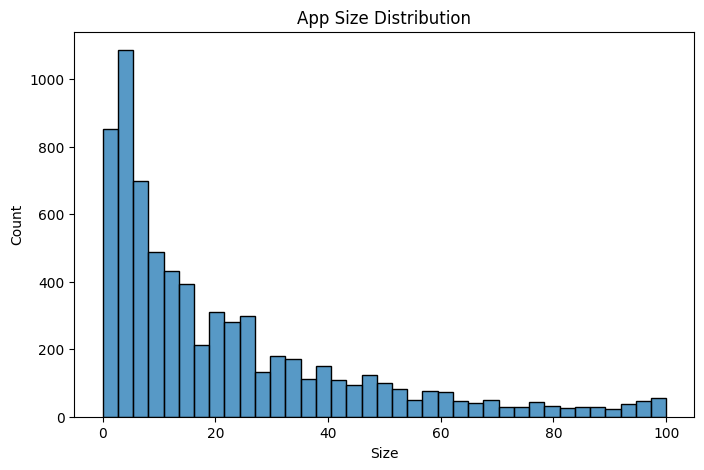

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(apps['Size'])
plt.title('App Size Distribution')
plt.show()

#####Analyze Installs

In [40]:
apps[['App','Installs']].sort_values(
    by='Installs',
    ascending=False
).head(10)

,App,Installs
2977,Google News,1000000000
1356,Subway Surfers,1000000000
2527,SHAREit - Transfer & Share,500000000
1364,Pou,500000000
1363,Temple Run 2,500000000
2739,Dropbox,500000000
311,imo free video calls and chat,500000000
342,UC Browser - Fast Download Private & Secure,500000000
1357,Candy Crush Saga,500000000
4623,Samsung Health,500000000


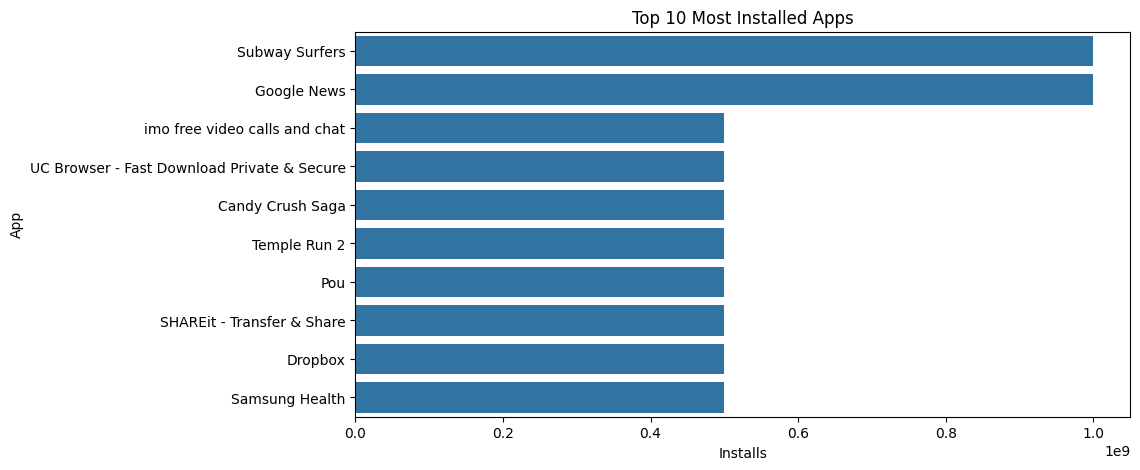

In [41]:
top10 = apps.nlargest(10,'Installs')

plt.figure(figsize=(10,5))
sns.barplot(x='Installs', y='App', data=top10)
plt.title('Top 10 Most Installed Apps')
plt.show()

###Analyze Pricing Trends

Free vs Paid Apps

In [42]:
apps['Type'].value_counts()

,count
Type,
Free,6482
Paid,539


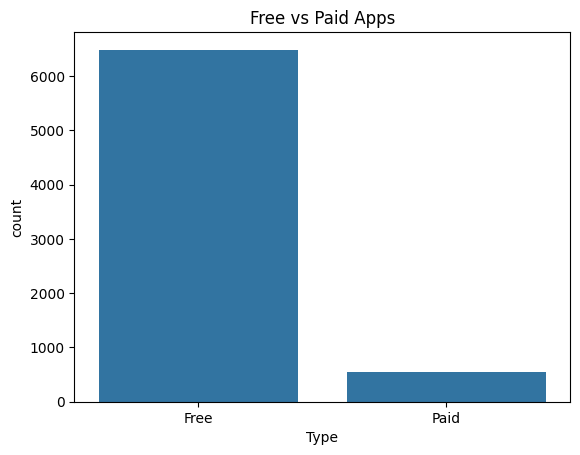

In [43]:
sns.countplot(x='Type', data=apps)
plt.title('Free vs Paid Apps')
plt.show()

###Paid App Price Distribution

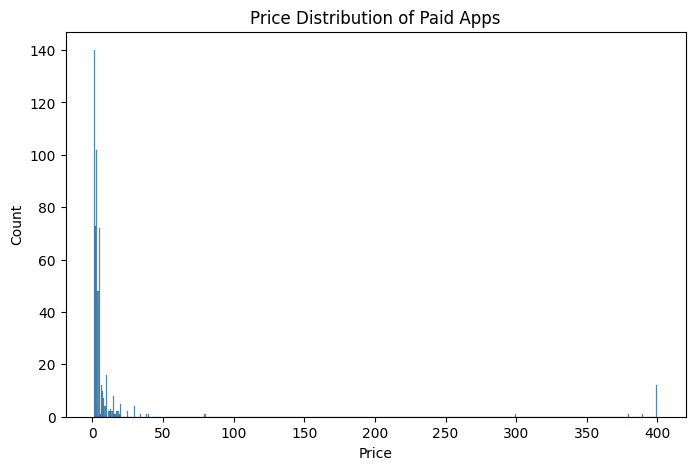

In [44]:
paid = apps[apps['Type']=='Paid']

plt.figure(figsize=(8,5))
sns.histplot(paid['Price'])
plt.title('Price Distribution of Paid Apps')
plt.show()

##SENTIMENT ANALYSIS

Sentiment Distribution

In [45]:
reviews['Sentiment'].value_counts()

,count
Sentiment,
Positive,23998
Negative,8271
Neutral,5158


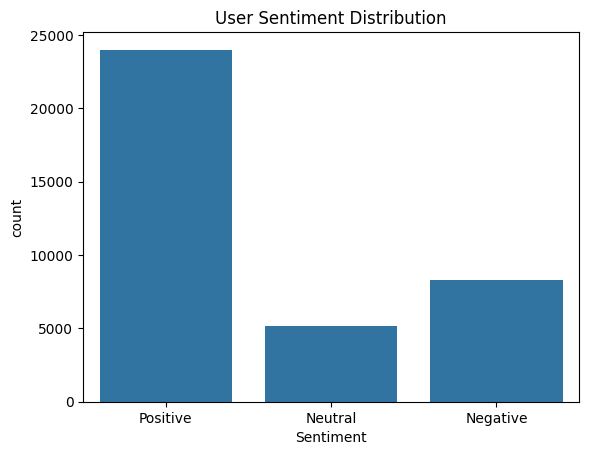

In [46]:
sns.countplot(x='Sentiment', data=reviews)
plt.title('User Sentiment Distribution')
plt.show()

In [47]:
reviews['Sentiment'].value_counts(normalize=True)*100

,proportion
Sentiment,
Positive,64.119486
Negative,22.099019
Neutral,13.781495


####Sentiment by Category

In [48]:
merged = pd.merge(
    apps,
    reviews,
    on='App',
    how='inner'
)

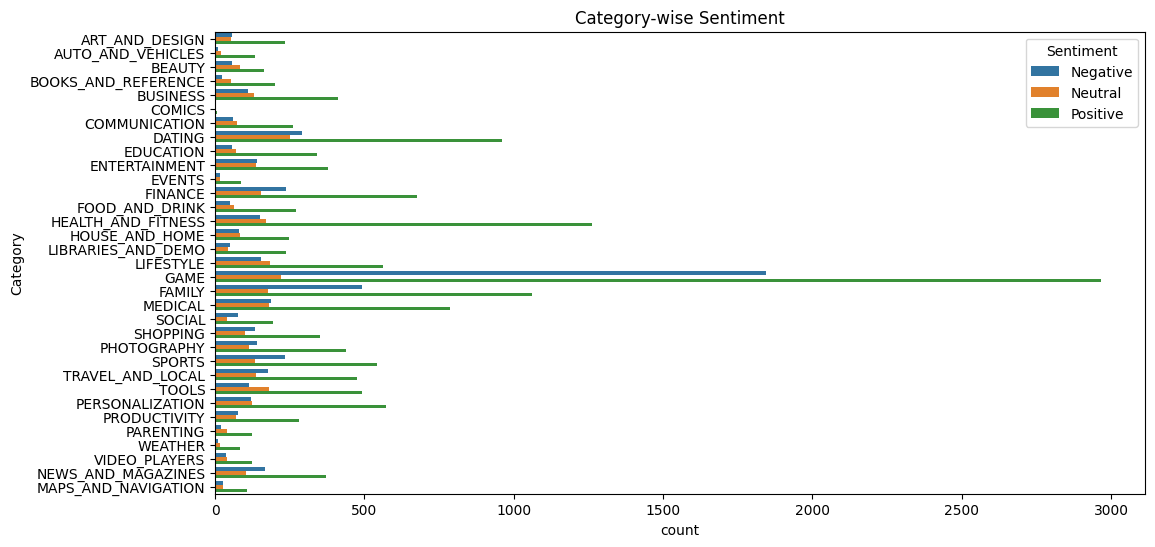

In [49]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Category',
    hue='Sentiment',
    data=merged
)

plt.title('Category-wise Sentiment')
plt.show()

##INTERACTIVE VISUALIZATION

Rating vs Installs

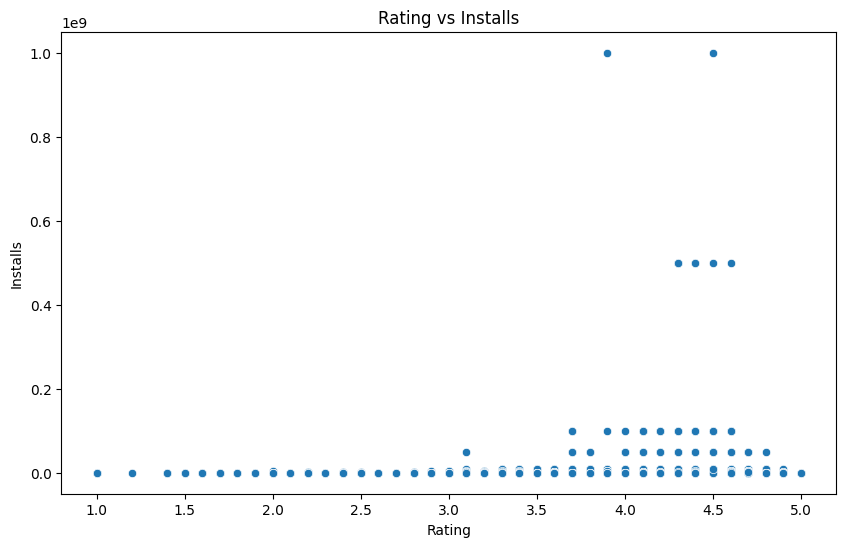

In [50]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Rating',
    y='Installs',
    data=apps
)

plt.title('Rating vs Installs')
plt.show()

Rating vs Category

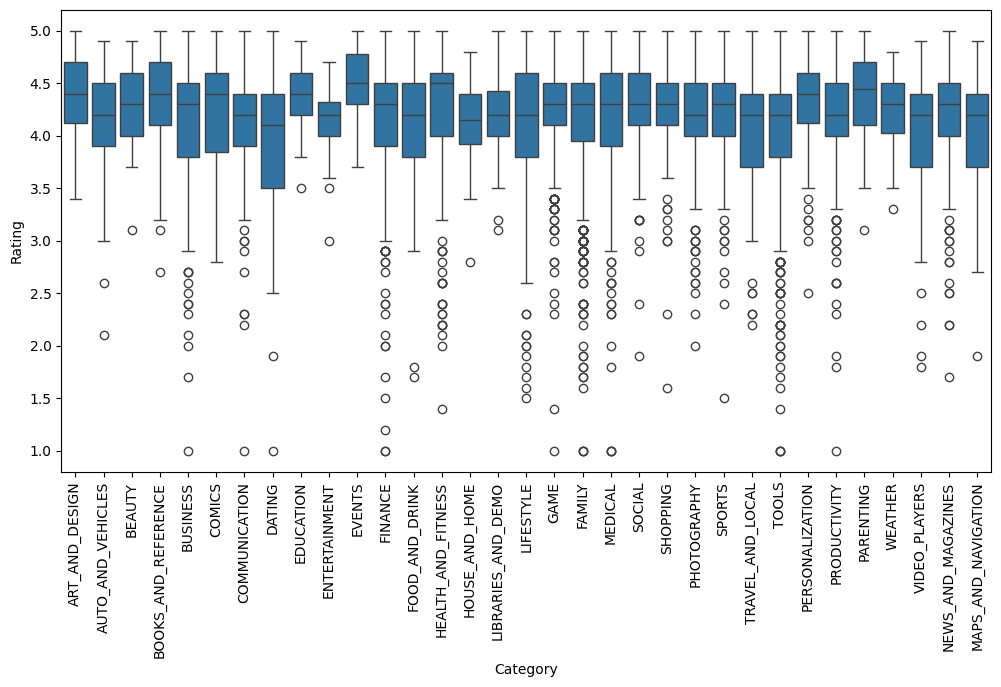

In [51]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Category',
    y='Rating',
    data=apps
)

plt.xticks(rotation=90)
plt.show()

Price vs Rating

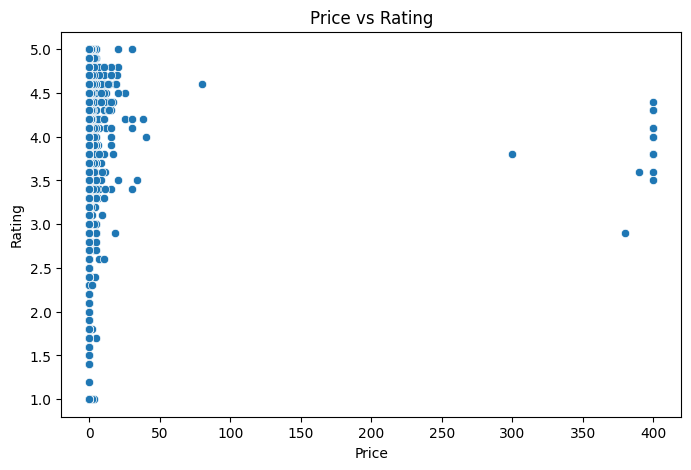